# MWE 49 - Three-dimensional FEM manufactured solutions

This experiment exercises the three-dimensional Brinkman weak forms on a
tetrahedral unit-cube mesh. The exact velocity is generated from derivatives
of a polynomial boundary bubble, so it vanishes on the boundary and is
exactly divergence-free. The forcing is derived automatically from the exact
velocity and pressure.

The low-order `P1/DG0` branch uses the triangular-face subscale (`face3d`)
pressure-jump coefficient from the 3D verification study. The face solve and
its refinement level are explicit numerical inputs.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import NullLocator

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.examples.mms import (
    available_mms_methods,
    bubble_case_3d,
    run_mms_convergence,
)
from voids.fem.singlephase import FEniCSSolverOptions

plt.ioff()

## Reproducible configuration

The default sequence is a quick verification run. Extend it to
`(4, 6, 8, 10, 12, 16, 20)` for comparison with the full linear-element
study, or through `30` for the focused low-order sequence.

In [2]:
viscosity = 1.0e-2
reaction = 1.0
resolutions = (4, 6, 8)
methods = available_mms_methods()
face_refinement = 24
absolute_rate_tolerance = 0.35
solver_options = FEniCSSolverOptions.superlu_direct()

case = bubble_case_3d(
    viscosity=viscosity,
    reaction=reaction,
)

## Run the refinement studies

In [3]:
studies = {}
for method in methods:
    print(f"Running {method} on {resolutions}")
    studies[method] = run_mms_convergence(
        case,
        method=method,
        resolutions=resolutions,
        options=solver_options,
        face_refinement=face_refinement,
        keep_solution=False,
    )

rows = []
for method, study in studies.items():
    rows.extend({"method": method, **row} for row in study.as_dicts())
results = pd.DataFrame(rows)
display(results)

Running taylor_hood on (4, 6, 8)


Running usfem_p1dg0 on (4, 6, 8)


Running usfem_p1dg1 on (4, 6, 8)


,method,resolution,h,num_cells,num_dofs,solve_seconds,velocity_l2_error,velocity_h1_error,pressure_l2_error,divergence_l2,velocity_l2_rate,velocity_h1_rate,pressure_l2_rate,divergence_l2_rate
0,taylor_hood,4,0.250000,384,2312,0.065051,0.175212,3.398694,0.067368,3.178737,NaN,NaN,NaN,NaN
1,taylor_hood,6,0.166667,1296,6934,0.392937,0.042794,1.452734,0.027703,1.393557,3.476487,2.096220,2.191627,2.033775
2,taylor_hood,8,0.125000,3072,15468,2.688684,0.013187,0.669124,0.014831,0.642767,4.092002,2.694759,2.171900,2.689885
3,usfem_p1dg0,4,0.250000,384,759,0.016866,0.117739,1.030308,0.249550,0.185642,NaN,NaN,NaN,NaN
4,usfem_p1dg0,6,0.166667,1296,2325,0.100842,0.069864,0.713499,0.157186,0.243953,1.287189,0.906197,1.140000,-0.673692
5,usfem_p1dg0,8,0.125000,3072,5259,0.617063,0.042070,0.517874,0.102569,0.223001,1.763175,1.113904,1.483900,0.312158
6,usfem_p1dg1,4,0.250000,384,1911,0.046718,0.085700,0.850897,0.060454,0.212587,NaN,NaN,NaN,NaN
7,usfem_p1dg1,6,0.166667,1296,6213,0.713122,0.046235,0.594772,0.032679,0.214979,1.521983,0.883218,1.517119,-0.027595
8,usfem_p1dg1,8,0.125000,3072,14475,5.174029,0.027923,0.450905,0.022900,0.187279,1.752992,0.962591,1.236120,0.479494


## Verify observed rates

In [4]:
rate_rows = []
for method, study in studies.items():
    study.assert_expected_rates(
        absolute_tolerance=absolute_rate_tolerance,
    )
    rate_rows.append(
        {
            "method": method,
            "facet_law": study.metadata["facet_law"],
            "face_refinement": study.metadata["face_refinement"],
            **{f"observed_{name}": value for name, value in study.last_rates.items()},
            **{
                f"nominal_{name}": value
                for name, value in study.expected_rates.as_dict().items()
            },
        }
    )
rate_table = pd.DataFrame(rate_rows)
display(rate_table)

,method,facet_law,face_refinement,observed_velocity_l2,observed_velocity_h1,observed_pressure_l2,observed_divergence_l2,nominal_velocity_l2,nominal_velocity_h1,nominal_pressure_l2
0,taylor_hood,NaN,NaN,4.092002,2.694759,2.17190,2.689885,3.0,2.0,2.0
1,usfem_p1dg0,face3d,24.0,1.763175,1.113904,1.48390,0.312158,2.0,1.0,1.0
2,usfem_p1dg1,face3d,24.0,1.752992,0.962591,1.23612,0.479494,2.0,1.0,1.0


## Convergence plot

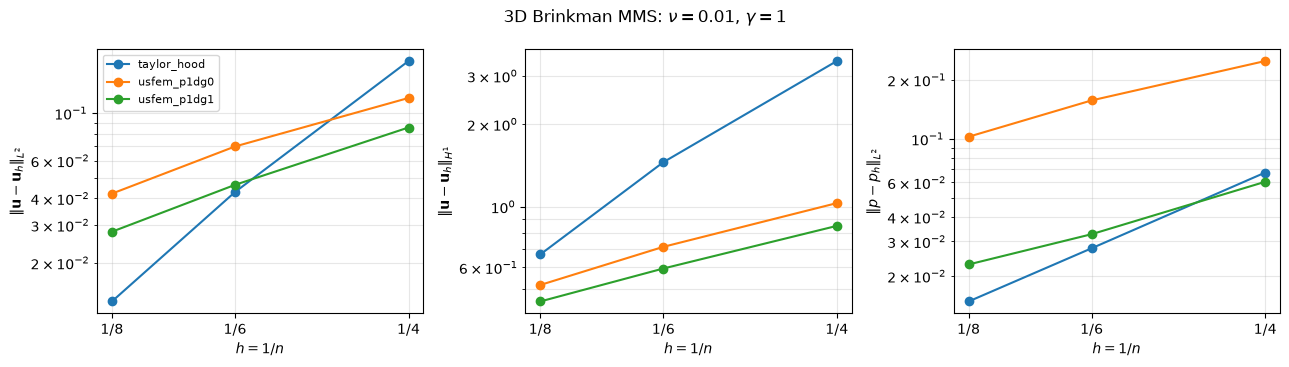

In [5]:
metric_labels = {
    "velocity_l2_error": r"$\|\mathbf{u}-\mathbf{u}_h\|_{L^2}$",
    "velocity_h1_error": r"$\|\mathbf{u}-\mathbf{u}_h\|_{H^1}$",
    "pressure_l2_error": r"$\|p-p_h\|_{L^2}$",
}
figure, axes = plt.subplots(1, 3, figsize=(13, 3.7))
for axis, (metric, label) in zip(axes, metric_labels.items()):
    for method, group in results.groupby("method"):
        axis.loglog(
            group["h"],
            group[metric],
            marker="o",
            label=method,
        )
    tick_values = [1.0 / resolution for resolution in reversed(resolutions)]
    axis.set_xticks(tick_values)
    axis.set_xticklabels([f"1/{resolution}" for resolution in reversed(resolutions)])
    axis.xaxis.set_minor_locator(NullLocator())
    axis.set_xlabel(r"$h=1/n$")
    axis.set_ylabel(label)
    axis.grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)
figure.suptitle(rf"3D Brinkman MMS: $\nu={viscosity:g}$, $\gamma={reaction:g}$")
figure.tight_layout()
display(figure)
plt.close(figure)

## Interpretation and limitations

- The `face3d` coefficient is a candidate three-dimensional extension, not a
  theorem already established for discontinuous pressure on tetrahedra.
- `face_refinement=24` controls the small reference-triangle finite-element
  solve used to compute the scalar pressure-jump coefficient.
- These results verify constant-coefficient smooth solutions. They do not by
  themselves establish robustness for high-contrast vug coefficients.
- Divergence is a diagnostic for the raw conforming velocity. Raviart-Thomas
  conservative recovery is not part of this MMS API yet.